In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from xgboost import XGBRegressor


project_root = Path.cwd().parent

demand_path = (
    project_root
    / "data"
    / "processed"
    / "vic_demand_2024-07_to_2026-06.parquet"
)

weather_path = (
    project_root
    / "data"
    / "processed"
    / "melbourne_weather_2024-07_to_2026-06.parquet"
)

df = pd.read_parquet(demand_path)
weather = pd.read_parquet(weather_path)

df = df[
    df["SETTLEMENTDATE"] < pd.Timestamp("2026-07-01")
].copy()

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

weather = (
    weather
    .rename(columns={"SETTLEMENTDATE": "WEATHER_TIME"})
    .sort_values("WEATHER_TIME")
    .reset_index(drop=True)
)

df = pd.merge_asof(
    df,
    weather,
    left_on="SETTLEMENTDATE",
    right_on="WEATHER_TIME",
    direction="backward",
)

In [2]:
FORECAST_HORIZON = 6

df["FORECAST_TIME"] = (
    df["SETTLEMENTDATE"]
    + pd.Timedelta(minutes=30)
)

df["target_30m"] = (
    df["TOTALDEMAND"]
    .shift(-FORECAST_HORIZON)
)

# Current and lagged demand
df["demand_current"] = df["TOTALDEMAND"]
df["demand_lag_5m"] = df["TOTALDEMAND"].shift(1)
df["demand_lag_15m"] = df["TOTALDEMAND"].shift(3)
df["demand_lag_30m"] = df["TOTALDEMAND"].shift(6)
df["demand_lag_1h"] = df["TOTALDEMAND"].shift(12)
df["demand_lag_2h"] = df["TOTALDEMAND"].shift(24)

# Historical comparable times
df["same_time_yesterday"] = (
    df["TOTALDEMAND"]
    .shift(288 - FORECAST_HORIZON)
)

df["same_time_last_week"] = (
    df["TOTALDEMAND"]
    .shift(2016 - FORECAST_HORIZON)
)

# Recent trajectory
df["change_15m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(3)
)

df["change_30m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(6)
)

df["change_1h"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(12)
)

# Rolling statistics
df["rolling_mean_30m"] = (
    df["TOTALDEMAND"]
    .rolling(6)
    .mean()
)

df["rolling_mean_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .mean()
)

df["rolling_std_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .std()
)

# Calendar features
df["target_hour"] = df["FORECAST_TIME"].dt.hour
df["target_minute"] = df["FORECAST_TIME"].dt.minute
df["target_day_of_week"] = df["FORECAST_TIME"].dt.dayofweek
df["target_month"] = df["FORECAST_TIME"].dt.month

df["target_is_weekend"] = (
    df["target_day_of_week"] >= 5
).astype(int)

In [3]:
base_features = [
    "demand_current",
    "demand_lag_5m",
    "demand_lag_15m",
    "demand_lag_30m",
    "demand_lag_1h",
    "demand_lag_2h",
    "same_time_yesterday",
    "same_time_last_week",
    "change_15m",
    "change_30m",
    "change_1h",
    "rolling_mean_30m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "target_hour",
    "target_minute",
    "target_day_of_week",
    "target_month",
    "target_is_weekend",
]

weather_features = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
]

final_features = (
    base_features
    + weather_features
)

model_df = df.dropna(
    subset=final_features + ["target_30m"]
).copy()

development = model_df[
    model_df["FORECAST_TIME"] < "2026-05-01"
].copy()

test = model_df[
    (model_df["FORECAST_TIME"] >= "2026-05-01")
    & (model_df["FORECAST_TIME"] < "2026-07-01")
].copy()

print(
    f"Development: {len(development):,} rows | "
    f"{development['FORECAST_TIME'].min()} → "
    f"{development['FORECAST_TIME'].max()}"
)

print(
    f"Test:        {len(test):,} rows | "
    f"{test['FORECAST_TIME'].min()} → "
    f"{test['FORECAST_TIME'].max()}"
)

Development: 190,655 rows | 2024-07-08 00:05:00 → 2026-04-30 23:55:00
Test:        17,568 rows | 2026-05-01 00:00:00 → 2026-06-30 23:55:00


In [4]:
final_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

final_model.fit(
    development[final_features],
    development["target_30m"],
)

test["final_forecast"] = final_model.predict(
    test[final_features]
)

test["persistence_forecast"] = (
    test["demand_current"]
)

In [6]:
final_mae = mean_absolute_error(
    test["target_30m"],
    test["final_forecast"],
)

final_rmse = np.sqrt(
    mean_squared_error(
        test["target_30m"],
        test["final_forecast"],
    )
)

persistence_mae = mean_absolute_error(
    test["target_30m"],
    test["persistence_forecast"],
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        test["target_30m"],
        test["persistence_forecast"],
    )
)

improvement = (
    (persistence_mae - final_mae)
    / persistence_mae
    * 100
)

print("FINAL HOLDOUT TEST RESULTS")
print("--------------------------")
print(f"Persistence MAE:  {persistence_mae:.2f} MW")
print(f"Persistence RMSE: {persistence_rmse:.2f} MW")
print()
print(f"Final model MAE:  {final_mae:.2f} MW")
print(f"Final model RMSE: {final_rmse:.2f} MW")
print()
print(
    f"Improvement over persistence: "
    f"{improvement:.2f}%"
)

FINAL HOLDOUT TEST RESULTS
--------------------------
Persistence MAE:  179.78 MW
Persistence RMSE: 222.41 MW

Final model MAE:  78.34 MW
Final model RMSE: 107.71 MW

Improvement over persistence: 56.43%


In [7]:
test["error"] = (
    test["target_30m"]
    - test["final_forecast"]
)

test["absolute_error"] = (
    test["error"].abs()
)

print(
    test["absolute_error"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    17568.000000
mean        78.336596
std         73.926838
min          0.007480
50%         57.445693
75%        105.202808
90%        173.885416
95%        226.874111
99%        342.520477
max        684.164824
Name: absolute_error, dtype: float64


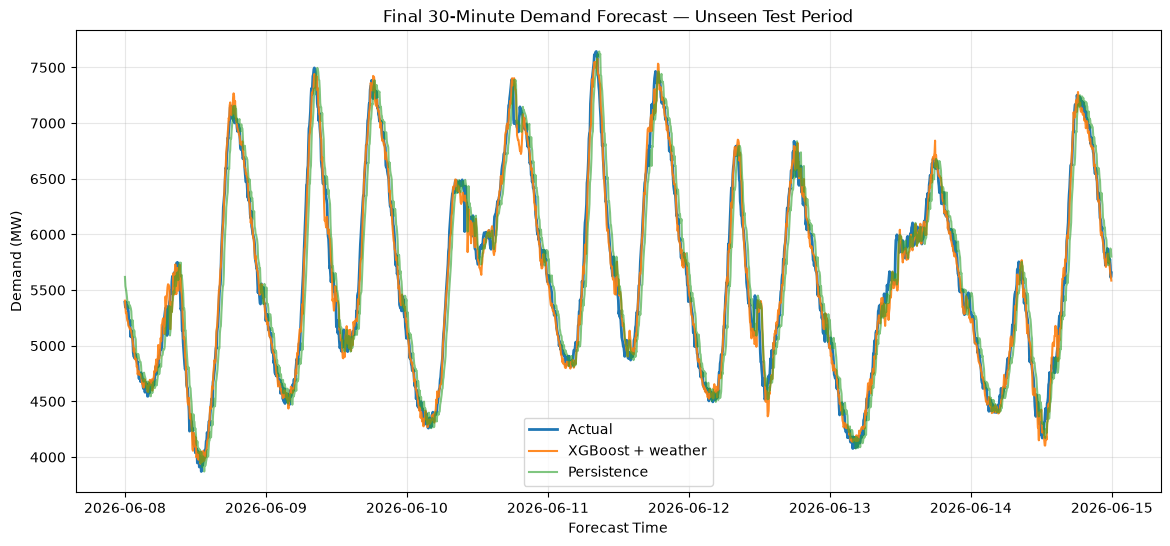

In [8]:
plot_start = pd.Timestamp("2026-06-08")
plot_end = plot_start + pd.Timedelta(days=7)

plot_data = test[
    (test["FORECAST_TIME"] >= plot_start)
    & (test["FORECAST_TIME"] < plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["target_30m"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["final_forecast"],
    label="XGBoost + weather",
    alpha=0.9,
)

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["persistence_forecast"],
    label="Persistence",
    alpha=0.6,
)

plt.title(
    "Final 30-Minute Demand Forecast — Unseen Test Period"
)
plt.xlabel("Forecast Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Final holdout evaluation

The final model was selected using historical and rolling validation only.
The May–June 2026 holdout period remained unused during model and feature
selection.

The frozen XGBoost model was then retrained using all available development
data through April 2026 and evaluated once against the unseen May–June
holdout period.

### Final results

- Persistence MAE: 179.78 MW
- Persistence RMSE: 222.41 MW
- Final model MAE: 78.34 MW
- Final model RMSE: 107.71 MW
- MAE improvement over persistence: 56.43%

The final test MAE is close to the model's validation performance, providing
evidence that the forecasting approach generalises to unseen future data.

Absolute forecast error on the holdout period had:

- median: 57.4 MW
- 90th percentile: 173.9 MW
- 95th percentile: 226.9 MW
- 99th percentile: 342.5 MW

The model therefore substantially outperforms a strong short-term persistence
benchmark while maintaining similar performance on validation and unseen
test periods.